In [1]:
import sys
print(sys.executable)
print(sys.version)

/opt/anaconda3/envs/supplychain/bin/python
3.12.14 | packaged by Anaconda, Inc. | (main, Aug 27 2026, 14:38:15) [Clang 20.1.8 ]


In [2]:
import pandas as pd
import numpy as np
import os

print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Environment is working!")

Pandas: 3.0.5
NumPy: 2.5.2
Environment is working!


In [3]:
import os
import pandas as pd

# Path to raw data folder
DATA_PATH = "../data/raw/data_olias"

# List all files
files = os.listdir(DATA_PATH)

print("Files found:")
for file in files:
    print(file)

Files found:
olist_sellers_dataset.csv
product_category_name_translation.csv
olist_orders_dataset.csv
olist_order_items_dataset.csv
olist_customers_dataset.csv
olist_geolocation_dataset.csv
olist_order_payments_dataset.csv
olist_order_reviews_dataset.csv
olist_products_dataset.csv


In [4]:
datasets = {}

for file in files:
    if file.endswith(".csv"):
        dataset_name = file.replace(".csv", "")
        file_path = os.path.join(DATA_PATH, file)

        datasets[dataset_name] = pd.read_csv(file_path)

        print(f"\n{'='*60}")
        print(dataset_name)
        print("Shape:", datasets[dataset_name].shape)
        print("Columns:")
        print(datasets[dataset_name].columns.tolist())


olist_sellers_dataset
Shape: (3095, 4)
Columns:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

product_category_name_translation
Shape: (71, 2)
Columns:
['product_category_name', 'product_category_name_english']

olist_orders_dataset
Shape: (99441, 8)
Columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

olist_order_items_dataset
Shape: (112650, 7)
Columns:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

olist_customers_dataset
Shape: (99441, 5)
Columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

olist_geolocation_dataset
Shape: (1000163, 5)
Columns:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geolocation_state']

olist_order_payments_dataset
Shape: (103

In [5]:
for name, df in datasets.items():
    print(f"{name}: {df.shape}")

olist_sellers_dataset: (3095, 4)
product_category_name_translation: (71, 2)
olist_orders_dataset: (99441, 8)
olist_order_items_dataset: (112650, 7)
olist_customers_dataset: (99441, 5)
olist_geolocation_dataset: (1000163, 5)
olist_order_payments_dataset: (103886, 5)
olist_order_reviews_dataset: (99224, 7)
olist_products_dataset: (32951, 9)


# 1. Data Quality Assessment

This section examines missing values, duplicate records, and data types
across the Olist datasets before preprocessing and integration.

In [6]:
# Data quality summary

for name, df in datasets.items():
    
    print(f"\n{'='*70}")
    print(f"DATASET: {name.upper()}")
    print(f"{'='*70}")
    
    print("\nShape:")
    print(df.shape)
    
    print("\nMissing Values:")
    missing = df.isnull().sum()
    print(missing[missing > 0])
    
    print("\nDuplicate Rows:")
    print(df.duplicated().sum())
    
    print("\nData Types:")
    print(df.dtypes)


DATASET: OLIST_SELLERS_DATASET

Shape:
(3095, 4)

Missing Values:
Series([], dtype: int64)

Duplicate Rows:
0

Data Types:
seller_id                   str
seller_zip_code_prefix    int64
seller_city                 str
seller_state                str
dtype: object

DATASET: PRODUCT_CATEGORY_NAME_TRANSLATION

Shape:
(71, 2)

Missing Values:
Series([], dtype: int64)

Duplicate Rows:
0

Data Types:
product_category_name            str
product_category_name_english    str
dtype: object

DATASET: OLIST_ORDERS_DATASET

Shape:
(99441, 8)

Missing Values:
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

Duplicate Rows:
0

Data Types:
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_da

In [7]:
orders = datasets["olist_orders_dataset"].copy()

# Convert timestamp columns
date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(orders[col])

print("Dataset Time Range:")
print("Start:", orders["order_purchase_timestamp"].min())
print("End:", orders["order_purchase_timestamp"].max())

print("\nOrder Status Distribution:")
print(orders["order_status"].value_counts())

Dataset Time Range:
Start: 2016-09-04 21:15:19
End: 2018-10-17 17:30:18

Order Status Distribution:
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64


In [8]:
# Create a missing values summary for all datasets

missing_summary = []

for name, df in datasets.items():
    missing = df.isnull().sum()
    
    for column, count in missing.items():
        if count > 0:
            missing_summary.append({
                "Dataset": name,
                "Column": column,
                "Missing Values": count,
                "Missing Percentage": round((count / len(df)) * 100, 2)
            })

missing_df = pd.DataFrame(missing_summary)

missing_df

,Dataset,Column,Missing Values,Missing Percentage
0,olist_orders_dataset,order_approved_at,160,0.16
1,olist_orders_dataset,order_delivered_carrier_date,1783,1.79
2,olist_orders_dataset,order_delivered_customer_date,2965,2.98
3,olist_order_reviews_dataset,review_comment_title,87656,88.34
4,olist_order_reviews_dataset,review_comment_message,58247,58.70
5,olist_products_dataset,product_category_name,610,1.85
6,olist_products_dataset,product_name_lenght,610,1.85
7,olist_products_dataset,product_description_lenght,610,1.85
8,olist_products_dataset,product_photos_qty,610,1.85
9,olist_products_dataset,product_weight_g,2,0.01


# 2. Data Preprocessing

Clean and prepare the core datasets required for supply chain analysis,
including orders, order items, products, customers, sellers, payments,
and customer reviews.

In [9]:
# Create working copies

orders = datasets["olist_orders_dataset"].copy()
order_items = datasets["olist_order_items_dataset"].copy()
customers = datasets["olist_customers_dataset"].copy()
products = datasets["olist_products_dataset"].copy()
sellers = datasets["olist_sellers_dataset"].copy()
payments = datasets["olist_order_payments_dataset"].copy()
reviews = datasets["olist_order_reviews_dataset"].copy()
category_translation = datasets["product_category_name_translation"].copy()

print("Working copies created successfully!")

Working copies created successfully!


In [10]:
# Convert order-related timestamps

order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in order_date_columns:
    orders[col] = pd.to_datetime(orders[col])

# Convert shipping date
order_items["shipping_limit_date"] = pd.to_datetime(
    order_items["shipping_limit_date"]
)

# Convert review timestamps
review_date_columns = [
    "review_creation_date",
    "review_answer_timestamp"
]

for col in review_date_columns:
    reviews[col] = pd.to_datetime(reviews[col])

print("Date conversion completed!")

Date conversion completed!


In [11]:
# Create delivered orders dataset for core supply chain analysis

delivered_orders = orders[
    orders["order_status"] == "delivered"
].copy()

print("Total orders:", len(orders))
print("Delivered orders:", len(delivered_orders))
print(
    "Delivered order percentage:",
    round(len(delivered_orders) / len(orders) * 100, 2),
    "%"
)

Total orders: 99441
Delivered orders: 96478
Delivered order percentage: 97.02 %


In [13]:
cleaned_datasets = {
    "orders": orders,
    "order_items": order_items,
    "customers": customers,
    "products": products,
    "sellers": sellers,
    "payments": payments,
    "reviews": reviews,
    "category_translation": category_translation
}

In [14]:
# ============================================================
# STEP 4: DATA CLEANING
# ============================================================

# 1. PRODUCTS DATA
# Fill missing category with 'unknown'
products['product_category_name'] = products[
    'product_category_name'
].fillna('unknown')

# Product physical/details missing values
product_numeric_cols = [
    'product_name_lenght',
    'product_description_lenght',
    'product_photos_qty',
    'product_weight_g',
    'product_length_cm',
    'product_height_cm',
    'product_width_cm'
]

for col in product_numeric_cols:
    products[col] = products[col].fillna(products[col].median())


# 2. REVIEWS DATA
# Text reviews are not the main focus of this project
# Fill missing text fields with empty strings
reviews['review_comment_title'] = reviews[
    'review_comment_title'
].fillna('')

reviews['review_comment_message'] = reviews[
    'review_comment_message'
].fillna('')


# 3. ORDERS DATA
# Keep missing delivery dates because they represent
# canceled/unavailable/non-delivered orders


# Check missing values after cleaning
print("=" * 60)
print("MISSING VALUES AFTER CLEANING")
print("=" * 60)

for name, df in cleaned_datasets.items():
    
    missing = df.isnull().sum()
    missing = missing[missing > 0]

    if len(missing) > 0:
        print(f"\n{name.upper()}")
        print(missing)
    else:
        print(f"\n{name.upper()}: No missing values")

MISSING VALUES AFTER CLEANING

ORDERS
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

ORDER_ITEMS: No missing values

CUSTOMERS: No missing values

PRODUCTS: No missing values

SELLERS: No missing values

PAYMENTS: No missing values

REVIEWS: No missing values

CATEGORY_TRANSLATION: No missing values


# 3. Master Supply Chain Dataset Construction

This section integrates the core Olist datasets to create an
order-item-level analytical dataset for supply chain analysis.

In [15]:
# Keep only delivered orders for the core analytical dataset

master_df = delivered_orders.copy()

print("Initial delivered orders:", master_df.shape)

Initial delivered orders: (96478, 8)


In [16]:
master_df = master_df.merge(
    order_items,
    on="order_id",
    how="inner"
)

print("After merging order items:", master_df.shape)

After merging order items: (110197, 14)


In [17]:
master_df = master_df.merge(
    products,
    on="product_id",
    how="left"
)

print("After merging products:", master_df.shape)

After merging products: (110197, 22)


In [18]:
master_df = master_df.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

# Use English category name where available
master_df["product_category"] = master_df[
    "product_category_name_english"
].fillna(master_df["product_category_name"])

print("After adding category translation:", master_df.shape)

After adding category translation: (110197, 24)


In [19]:
customer_info = customers[
    [
        "customer_id",
        "customer_unique_id",
        "customer_city",
        "customer_state"
    ]
]

master_df = master_df.merge(
    customer_info,
    on="customer_id",
    how="left"
)

print("After merging customers:", master_df.shape)

After merging customers: (110197, 27)


In [20]:
seller_info = sellers[
    [
        "seller_id",
        "seller_city",
        "seller_state"
    ]
].rename(
    columns={
        "seller_city": "seller_city",
        "seller_state": "seller_state"
    }
)

master_df = master_df.merge(
    seller_info,
    on="seller_id",
    how="left"
)

print("After merging sellers:", master_df.shape)

After merging sellers: (110197, 29)


In [21]:
# Aggregate payment information at order level

payment_summary = payments.groupby("order_id").agg(
    total_payment_value=("payment_value", "sum"),
    total_payment_installments=("payment_installments", "max"),
    payment_types=("payment_type", lambda x: ", ".join(x.unique()))
).reset_index()

print("Payment summary shape:", payment_summary.shape)

payment_summary.head()

Payment summary shape: (99440, 4)


,order_id,total_payment_value,total_payment_installments,payment_types
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


In [22]:
master_df = master_df.merge(
    payment_summary,
    on="order_id",
    how="left"
)

print("After merging payments:", master_df.shape)

After merging payments: (110197, 32)


In [23]:
# Check review records per order

review_counts = reviews["order_id"].value_counts()

print("Maximum reviews for a single order:", review_counts.max())

print("\nOrders with multiple reviews:")
print((review_counts > 1).sum())

Maximum reviews for a single order: 3

Orders with multiple reviews:
547


In [24]:
# Aggregate reviews at order level

review_summary = reviews.groupby("order_id").agg(
    average_review_score=("review_score", "mean"),
    review_count=("review_score", "count")
).reset_index()

print("Review summary shape:", review_summary.shape)

review_summary.head()

Review summary shape: (98673, 3)


,order_id,average_review_score,review_count
0,00010242fe8c5a6d1ba2dd792cb16214,5.0,1
1,00018f77f2f0320c557190d7a144bdd3,4.0,1
2,000229ec398224ef6ca0657da4fc703e,5.0,1
3,00024acbcdf0a6daa1e931b038114c75,4.0,1
4,00042b26cf59d7ce69dfabb4e55b4fd9,5.0,1


In [25]:
master_df = master_df.merge(
    review_summary,
    on="order_id",
    how="left"
)

print("After merging reviews:", master_df.shape)

After merging reviews: (110197, 34)


In [26]:
master_missing = (
    master_df.isnull()
    .sum()
    .sort_values(ascending=False)
)

master_missing[master_missing > 0]

product_category_name_english    1559
review_count                      827
average_review_score              827
order_approved_at                  15
order_delivered_customer_date       8
payment_types                       3
total_payment_installments          3
total_payment_value                 3
order_delivered_carrier_date        2
dtype: int64

In [27]:
# Final category variable

master_df["product_category"] = (
    master_df["product_category_name_english"]
    .fillna(master_df["product_category_name"])
    .fillna("unknown")
)

print(
    "Missing product categories:",
    master_df["product_category"].isna().sum()
)

Missing product categories: 0


In [28]:
master_df["review_count"] = master_df["review_count"].fillna(0)

In [29]:
master_df["has_review"] = (
    master_df["average_review_score"].notna()
).astype(int)

In [30]:
master_df["review_count"] = master_df["review_count"].fillna(0)

master_df["has_review"] = (
    master_df["average_review_score"].notna()
).astype(int)

print(
    master_df[
        ["average_review_score", "review_count", "has_review"]
    ].isnull().sum()
)

average_review_score    827
review_count              0
has_review                0
dtype: int64


In [31]:
payment_missing_orders = master_df[
    master_df["total_payment_value"].isna()
][
    [
        "order_id",
        "product_id",
        "price",
        "freight_value",
        "total_payment_value"
    ]
]

payment_missing_orders

,order_id,product_id,price,freight_value,total_payment_value
34056,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN
34057,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN
34058,bfbd0f9bdef84302105ad712db648a6c,5a6b04657a4c5ee34285d1e4619a96b4,44.99,2.83,NaN


In [32]:
missing_delivery_orders = master_df[
    master_df["order_delivered_customer_date"].isna()
][
    [
        "order_id",
        "order_status",
        "order_purchase_timestamp",
        "order_approved_at",
        "order_delivered_customer_date",
        "order_estimated_delivery_date"
    ]
].drop_duplicates()

missing_delivery_orders

,order_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_customer_date,order_estimated_delivery_date
3291,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,NaT,2017-12-18
22829,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,NaT,2018-07-16
48549,2ebdfc4f15f23b91474edf87475f108e,delivered,2018-07-01 17:05:11,2018-07-01 17:15:12,NaT,2018-07-30
87714,e69f75a717d64fc5ecdfae42b2e8e086,delivered,2018-07-01 22:05:55,2018-07-01 22:15:14,NaT,2018-07-30
91678,0d3268bad9b086af767785e3f0fc0133,delivered,2018-07-01 21:14:02,2018-07-01 21:29:54,NaT,2018-07-24
102597,2d858f451373b04fb5c984a1cc2defaf,delivered,2017-05-25 23:22:43,2017-05-25 23:30:16,NaT,2017-06-23
108162,ab7c89dc1bf4a1ead9d6ec1ec8968a84,delivered,2018-06-08 12:09:39,2018-06-08 12:36:39,NaT,2018-06-26
108601,20edc82cf5400ce95e1afacc25798b31,delivered,2018-06-27 16:09:12,2018-06-27 16:29:30,NaT,2018-07-19


In [33]:
# Remove records with missing actual delivery date
# from the master analytical dataset

master_df = master_df[
    master_df["order_delivered_customer_date"].notna()
].copy()

print("Master dataset shape:", master_df.shape)

Master dataset shape: (110189, 35)


In [34]:
# Check duplicate order-item combinations

duplicate_order_items = master_df.duplicated(
    subset=["order_id", "order_item_id"]
).sum()

print(
    "Duplicate order-item records:",
    duplicate_order_items
)

Duplicate order-item records: 0


# 4. Feature Engineering

Operational, temporal, and logistics-related features are created
to support demand analysis, supply chain performance evaluation,
and the subsequent circular supply chain optimization model.

In [35]:
master_df["delivery_time_days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_purchase_timestamp"]
).dt.total_seconds() / 86400

In [36]:
master_df["delivery_delay_days"] = (
    master_df["order_delivered_customer_date"]
    - master_df["order_estimated_delivery_date"]
).dt.total_seconds() / 86400

In [37]:
master_df["is_late_delivery"] = (
    master_df["delivery_delay_days"] > 0
).astype(int)

In [38]:
master_df["product_volume_cm3"] = (
    master_df["product_length_cm"]
    * master_df["product_height_cm"]
    * master_df["product_width_cm"]
)

In [39]:
master_df["freight_ratio"] = (
    master_df["freight_value"]
    / master_df["price"]
)

In [40]:
master_df[
    [
        "delivery_time_days",
        "delivery_delay_days",
        "is_late_delivery",
        "product_volume_cm3",
        "freight_ratio"
    ]
].describe()

,delivery_time_days,delivery_delay_days,is_late_delivery,product_volume_cm3,freight_ratio
count,110189.000000,110189.000000,110189.000000,110189.000000,110189.000000
mean,12.472246,-11.331987,0.079082,15172.581946,0.320822
std,9.445346,10.160368,0.269868,23237.435429,0.347791
min,0.533414,-146.016123,0.000000,168.000000,0.000000
25%,6.736192,-16.320440,0.000000,2850.000000,0.134544
50%,10.184201,-12.046447,0.000000,6460.000000,0.231837
75%,15.540810,-6.476655,0.000000,18144.000000,0.393250
max,209.628611,188.975081,1.000000,296208.000000,26.235294


## 4.1 Temporal and Demand Features

Temporal features are created from order purchase timestamps to analyze
demand patterns across time and support subsequent forecasting and
optimization.

In [41]:
# Purchase date features

master_df["purchase_date"] = master_df[
    "order_purchase_timestamp"
].dt.date

master_df["purchase_year"] = master_df[
    "order_purchase_timestamp"
].dt.year

master_df["purchase_month"] = master_df[
    "order_purchase_timestamp"
].dt.month

master_df["purchase_quarter"] = master_df[
    "order_purchase_timestamp"
].dt.quarter

master_df["purchase_weekday"] = master_df[
    "order_purchase_timestamp"
].dt.day_name()

master_df["purchase_hour"] = master_df[
    "order_purchase_timestamp"
].dt.hour

# Year-month variable for aggregation
master_df["year_month"] = master_df[
    "order_purchase_timestamp"
].dt.to_period("M").astype(str)

print("Temporal features created successfully!")

Temporal features created successfully!


In [42]:
monthly_demand = (
    master_df
    .groupby("year_month")
    .agg(
        total_items=("order_item_id", "count"),
        unique_orders=("order_id", "nunique"),
        total_revenue=("price", "sum"),
        total_freight=("freight_value", "sum")
    )
    .reset_index()
)

monthly_demand.head(10)

,year_month,total_items,unique_orders,total_revenue,total_freight
0,2016-09,3,1,134.97,8.49
1,2016-10,313,265,40325.11,6165.55
2,2016-12,1,1,10.90,8.72
3,2017-01,913,750,111798.36,15684.01
4,2017-02,1858,1653,234223.40,37015.92
5,2017-03,2897,2546,359198.85,55132.10
6,2017-04,2569,2303,340669.68,50142.72
7,2017-05,4003,3545,489159.25,77498.15
8,2017-06,3489,3135,421923.37,68127.00
9,2017-07,4416,3872,481604.52,84694.56


In [43]:
monthly_demand.describe()

,total_items,unique_orders,total_revenue,total_freight
count,23.000000,23.000000,23.000000,23.000000
mean,4790.826087,4194.347826,574793.431739,95571.560870
std,2845.199908,2480.924124,337222.230371,58144.963571
min,1.000000,1.000000,10.900000,8.490000
25%,2733.000000,2424.500000,349934.265000,52637.410000
50%,4797.000000,4193.000000,607399.670000,93677.820000
75%,7330.000000,6453.000000,861539.220000,152236.145000
max,8474.000000,7288.000000,987648.070000,167241.990000


In [45]:
import matplotlib.pyplot as plt

print("Matplotlib is working!")

Matplotlib is working!


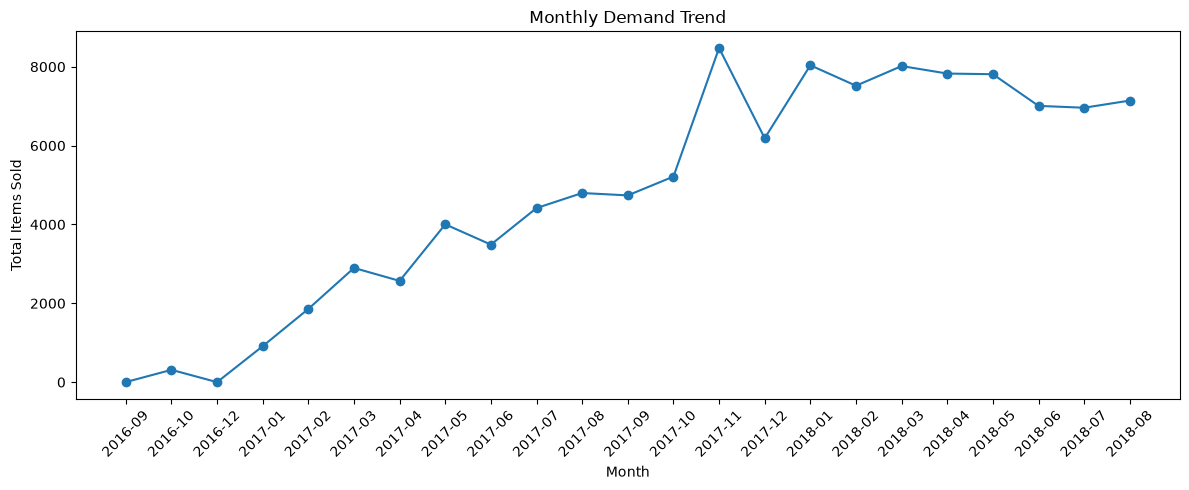

In [46]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["year_month"],
    monthly_demand["total_items"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Demand Trend")
plt.xlabel("Month")
plt.ylabel("Total Items Sold")

plt.tight_layout()
plt.show()

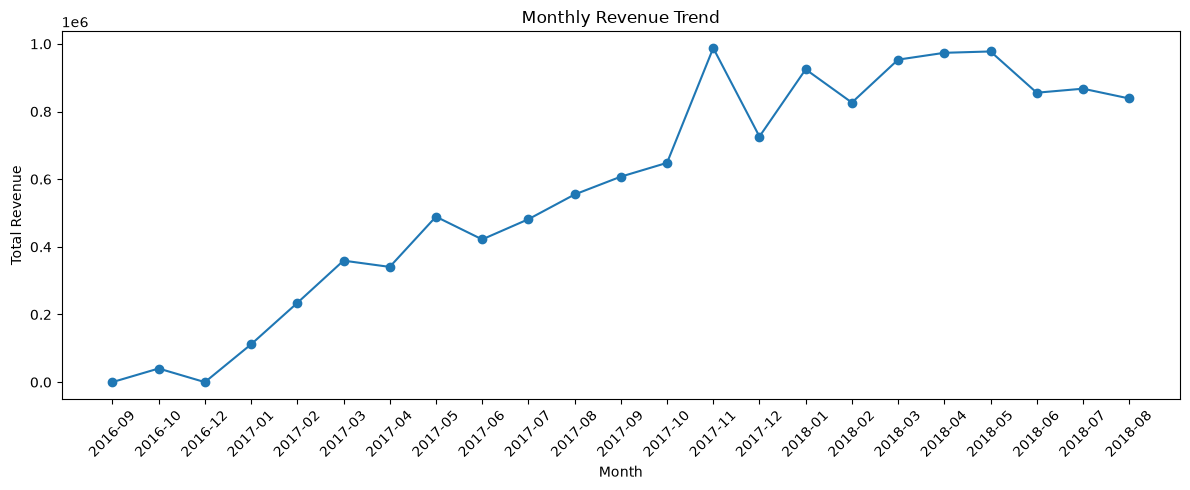

In [47]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_demand["year_month"],
    monthly_demand["total_revenue"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.show()

In [48]:
import os

# Create processed data directory if it doesn't exist
os.makedirs("../data/processed", exist_ok=True)

# Save master dataset
master_df.to_csv(
    "../data/processed/master_supply_chain_data.csv",
    index=False
)

# Save monthly demand dataset
monthly_demand.to_csv(
    "../data/processed/monthly_demand.csv",
    index=False
)

print("Processed datasets saved successfully!")

Processed datasets saved successfully!
